# bike sharing demand (regression)

In [32]:
import xgboost as xgb ## XGBoost 불러오기
from xgboost import plot_importance ## Feature Importance를 불러오기 위함
from sklearn import datasets
from sklearn import tree
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [33]:
train  = pd.read_csv('train.csv', index_col=['datetime'], parse_dates=['datetime'])
test  = pd.read_csv('test.csv', index_col=['datetime'], parse_dates=['datetime'])

In [34]:
train.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [35]:
train.tail()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,,,,,,,,,,,
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129
2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88


In [36]:
test.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
datetime,,,,,,,,
2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


In [37]:
test.tail()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
datetime,,,,,,,,
2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014
2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014
2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014
2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981
2012-12-31 23:00:00,1,0,1,1,10.66,13.635,65,8.9981


In [38]:
train.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [39]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   casual      10886 non-null  int64  
 9   registered  10886 non-null  int64  
 10  count       10886 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 1020.6 KB


<Axes: xlabel='datetime'>

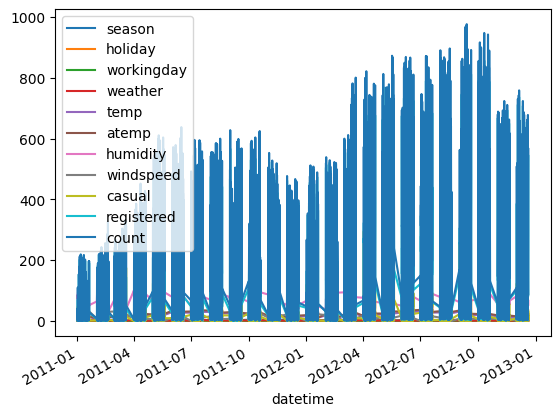

In [40]:
train.plot()

In [41]:
X_data = train[['season','holiday', 'workingday', 'weather', 
               'temp', 'atemp', 'humidity', 'windspeed']].values
y_data = train[['count']].values

In [42]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, test_size=0.2) # train과 test를 8:2로 분할

In [43]:
model = tree.DecisionTreeClassifier()

In [44]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [45]:
y = model.predict(X_train)

In [46]:
print(model.score(X_train, y_train))

0.8380799265043638


In [47]:
print(model.score(X_val, y_val))

0.01147842056932966


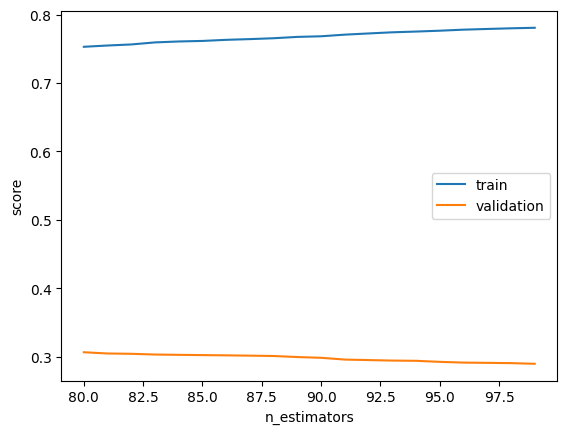

In [48]:
train_score = []
val_score = []
n_range = range(80, 100)

for n in n_range:
    model = xgb.XGBRegressor(n_estimators=n, learning_rate=0.08, gamma=0, subsample=0.75,
                           colsample_bytree=1, max_depth=10)
    model.fit(X_train, y_train)
    train_score.append(model.score(X_train, y_train))
    val_score.append(model.score(X_val, y_val))

plt.figure()
plt.plot(n_range, train_score, label='train')
plt.plot(n_range, val_score, label='validation')
plt.legend()
plt.xlabel('n_estimators')
plt.ylabel('score')
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

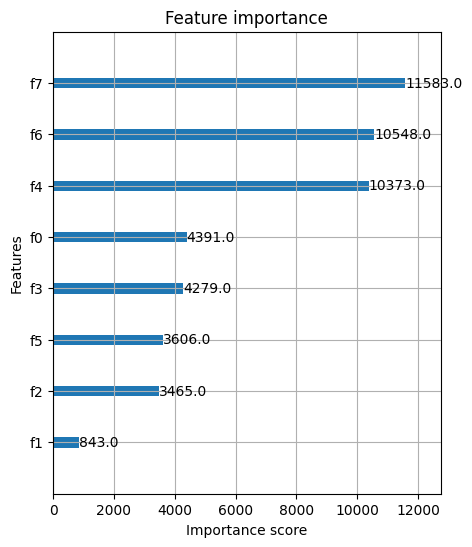

In [49]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(5, 6))
plot_importance(model, ax=ax)

In [50]:
X_test = test[['season','holiday', 'workingday', 'weather', 
               'temp', 'atemp', 'humidity', 'windspeed']].values

In [51]:
y_pred = model.predict(X_test)

In [52]:
print(y_pred)

[142.21951   38.179153  38.179153 ...  66.457535  51.923035  46.75339 ]


In [53]:
test['count'] = y_pred

In [54]:
test.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
datetime,,,,,,,,,
2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,142.219513
2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,38.179153
2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,38.179153
2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,49.487240
2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,49.487240


In [55]:
save_df = test.drop(columns=['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed'])

In [56]:
save_df.head()

,count
datetime,
2011-01-20 00:00:00,142.219513
2011-01-20 01:00:00,38.179153
2011-01-20 02:00:00,38.179153
2011-01-20 03:00:00,49.487240
2011-01-20 04:00:00,49.487240


In [57]:
save_df['count'] = save_df['count'].astype(int)

In [58]:
save_df.head()

,count
datetime,
2011-01-20 00:00:00,142
2011-01-20 01:00:00,38
2011-01-20 02:00:00,38
2011-01-20 03:00:00,49
2011-01-20 04:00:00,49


In [59]:
save_df.to_csv('submission.csv', sep=',')

In [60]:
from sklearn import metrics

y_pred = model.predict(X_val)
print('mean_absolute_error: ', metrics.mean_absolute_error(y_val, y_pred)) # best는 0.0
print('mean_squared_error: ', metrics.mean_squared_error(y_val, y_pred)) # best는 0.0
print(f'MAPE: ', metrics.mean_absolute_percentage_error(y_val, y_pred) * 100) # best는 0.0%
print('r2_score: ', metrics.r2_score(y_val, y_pred)) # best는 1.0

mean_absolute_error:  106.68114471435547
mean_squared_error:  21863.4296875
MAPE:  440.65656661987305
r2_score:  0.28953027725219727
